In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from numpy import expand_dims
from numpy import mean
from numpy import ones
from numpy.random import randn
from numpy.random import randint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

0.0 MB


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),( 0.5, 0.5, 0.5))
])


In [4]:
train_dataset = datasets.CIFAR10(root='./data', train= True, download=True, transform=transform)

dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True)

c:\Users\semen\AppData\Local\pypoetry\Cache\virtualenvs\priceclassifier-0_d4FkaK-py3.13\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
def wassersain_loss(y_true, y_pred):
    return torch.mean(y_true* y_pred)

In [6]:
def generate_real_sample(dataset, n_sample):
    ix = randint(0, dataset.shape[0], n_sample)
    X = dataset[ix]
    y = -ones((n_sample, 1))
    return X, y

In [7]:
class ClipConstrain:
    def __init__(self, clip_value):
        self.clip_value = clip_value

    def __call__(self, module):
        # Применяем clamp ко всем параметрам (весам и смещениям)
        for param in module.parameters():
            param.data.clamp_(-self.clip_value, self.clip_value)

In [8]:
class Critic(nn.Module):
    def __init__(self,in_chanel = 3):
        super(Critic,self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_chanel, 64, kernel_size = 4, stride = 2, padding=1),
            #nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 64, kernel_size = 4, stride = 2, padding=1),
            #nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 1)
        )

        self.initialize_weights()
    def forward(self,x):
        return self.model(x)
    
    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.normal_(
                    m.weight,
                    mean=0.0,
                    std=0.02
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

In [9]:
class Generator(nn.Module):

    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.fc = nn.Linear(
            latent_dim,
            128 * 8 * 8
        )

        self.net = nn.Sequential(

            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(
                128,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(
                128,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                128,
                3,
                kernel_size=7,
                padding=3
            ),

            nn.Tanh()
        )

    def forward(self, x):

        x = self.fc(x)

        x = x.view(-1, 128, 8, 8)

        x = self.net(x)

        return x

In [10]:
class Wgan(nn.Module):
    def __init__(self, generator , critic):
        super(Wgan, self).__init__()

        self.generator = generator
        self.critic = critic

        for layer in self.critic.modules():
            if not isinstance(layer, nn.BatchNorm2d):
                for param in layer.parameters():
                    param.requires_grad = False
    
    def forward(self, z):
        fake_image = self.generator(z)

        out = self.critic(fake_image)

        return out

In [11]:
import torch

# ---------------------------------
# Generate latent points
# ---------------------------------

def generate_latent_points(latent_dim, n_samples, device):

    z = torch.randn(
        n_samples,
        latent_dim,
        device=device
    )

    return z


# ---------------------------------
# Generate fake samples
# ---------------------------------

def generate_fake_samples(
    generator,
    latent_dim,
    n_samples,
    device
):

    # latent vectors
    z = generate_latent_points(
        latent_dim,
        n_samples,
        device
    )

    # disable gradients
    with torch.no_grad():

        fake_images = generator(z)

    # WGAN labels
    y = torch.ones(
        (n_samples, 1),
        device=device
    )

    return fake_images, y

epoch=1 c_real=-0.013 c_fake=-0.002 g=0.003
epoch=1 c_real=-0.014 c_fake=-0.026 g=0.042
epoch=1 c_real=-0.032 c_fake=-0.047 g=0.063
epoch=1 c_real=-0.064 c_fake=-0.044 g=0.060
epoch=1 c_real=-0.077 c_fake=-0.021 g=0.040
epoch=1 c_real=-0.114 c_fake=-0.043 g=0.069
epoch=1 c_real=-0.170 c_fake=-0.112 g=0.141
epoch=1 c_real=-0.213 c_fake=-0.107 g=0.152
epoch=1 c_real=-0.156 c_fake=-0.030 g=0.090
epoch=1 c_real=-0.151 c_fake=-0.018 g=0.052
epoch=1 c_real=-0.195 c_fake=0.005 g=0.025
epoch=1 c_real=-0.187 c_fake=0.040 g=0.016
epoch=1 c_real=-0.235 c_fake=-0.191 g=0.248
epoch=1 c_real=-0.302 c_fake=-0.392 g=0.445
epoch=1 c_real=-0.418 c_fake=-0.462 g=0.508
epoch=1 c_real=-0.442 c_fake=-0.295 g=0.352
epoch=1 c_real=-0.458 c_fake=0.191 g=-0.099
epoch=1 c_real=-0.432 c_fake=0.081 g=0.023
epoch=1 c_real=-0.403 c_fake=-0.216 g=0.302
epoch=1 c_real=-0.416 c_fake=-0.501 g=0.570
epoch=1 c_real=-0.477 c_fake=-0.721 g=0.787
epoch=1 c_real=-0.522 c_fake=-0.759 g=0.812
epoch=1 c_real=-0.656 c_fake=-0.521

KeyboardInterrupt: 

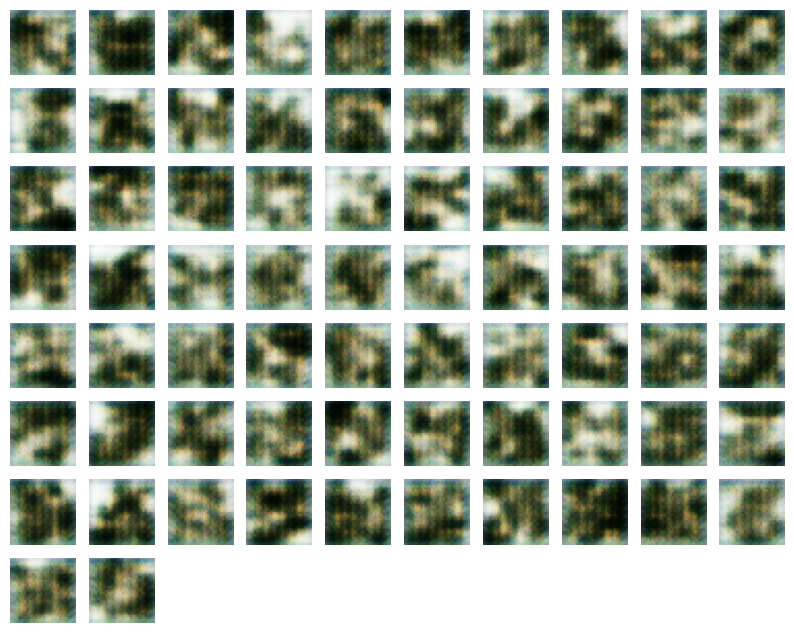

In [12]:
n_epochs = 10
batch_size = 512
half_batch = batch_size // 2
n_critic = 5
latent_dim = 100

generator = Generator(latent_dim).to(device)
critic = Critic().to(device)

optimizer_g = torch.optim.RMSprop(
    generator.parameters(),
    lr=0.00005
)

optimizer_c = torch.optim.RMSprop(
    critic.parameters(),
    lr=0.00005
)


constraint = ClipConstrain(0.01)


c1_hist = []
c2_hist = []
g_hist = []


for epoch in range(n_epochs):

    for real_images, _ in dataloader:

        # =========================
        # Train Critic
        # =========================

        for _ in range(n_critic):

            # ---------------------
            # Real images
            # ---------------------

            real_images = real_images.to(device)

            real_images = real_images[:half_batch]

            optimizer_c.zero_grad()

            real_labels = torch.ones(
                (real_images.size(0), 1),
                device=device
            )

            real_output = critic(real_images)

            c_loss_real = -torch.mean(
                real_labels * real_output
            )

            c_loss_real.backward()

            # ---------------------
            # Fake images
            # ---------------------

            z = torch.randn(
                half_batch,
                latent_dim,
                device=device
            )

            fake_images = generator(z)

            fake_labels = -torch.ones(
                (half_batch, 1),
                device=device
            )

            fake_output = critic(
                fake_images.detach()
            )

            c_loss_fake = -torch.mean(
                fake_labels * fake_output
            )

            c_loss_fake.backward()

            optimizer_c.step()

            # weight clipping
            constraint(critic)

        # =========================
        # Train Generator
        # =========================

        optimizer_g.zero_grad()

        z = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )

        generated_images = generator(z)

        generator_labels = torch.ones(
            (batch_size, 1),
            device=device
        )

        generator_output = critic(
            generated_images
        )

        g_loss = -torch.mean(
            generator_labels * generator_output
        )

        g_loss.backward()

        optimizer_g.step()

        # =========================
        # Save losses
        # =========================

        c1_hist.append(
            c_loss_real.item()
        )

        c2_hist.append(
            c_loss_fake.item()
        )

        g_hist.append(
            g_loss.item()
        )

        print(
            f"epoch={epoch+1} "
            f"c_real={c_loss_real.item():.3f} "
            f"c_fake={c_loss_fake.item():.3f} "
            f"g={g_loss.item():.3f} "
            f"c + c {(c_loss_real.item()+c_loss_fake.item()):.3f}")
        
        with torch.no_grad():

            z = torch.randn(
                100,
                latent_dim,
                device=device
            )

            fake_images = generator(z)

            # [-1, 1] -> [0, 1]
            fake_images = (fake_images + 1) / 2.0

            # to cpu + numpy
            fake_images = fake_images.cpu().numpy()

            plt.figure(figsize=(10, 10))

            for i in range(100):
            
                plt.subplot(10, 10, i + 1)

                plt.axis("off")

                # (C,H,W) -> (H,W,C)
                img = fake_images[i].transpose(1, 2, 0)

                plt.imshow(img)

            filename = f"plot_{epoch+1:04d}.png"

            plt.savefig(filename)

            plt.close()
            

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# SAVE GENERATED RGB IMAGES
# ==========================================

with torch.no_grad():

    z = torch.randn(
        100,
        latent_dim,
        device=device
    )

    fake_images = generator(z)

    # [-1, 1] -> [0, 1]
    fake_images = (fake_images + 1) / 2.0

    # to cpu + numpy
    fake_images = fake_images.cpu().numpy()

    plt.figure(figsize=(10, 10))

    for i in range(100):

        plt.subplot(10, 10, i + 1)

        plt.axis("off")

        # (C,H,W) -> (H,W,C)
        img = fake_images[i].transpose(1, 2, 0)

        plt.imshow(img)

    filename = f"plot_{epoch+1:04d}.png"

    plt.savefig(filename)

    plt.close()